## My Implementation of Gradient Descent along with some valuable notes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
def compute_cost(x, y, w, b): 
    """
    Compute Mean Squared Error cost for linear regression.

    Args:
        x (ndarray): Feature values, shape (m,)
        y (ndarray): Target values, shape (m,)
        w (float): Weight (slope)
        b (float): Bias (intercept)

    Returns:
        float: The cost (mean squared error)
    """
    m = x.shape[0]
    y_pred = np.dot(x,w)+b
    cost = 1/(2*m)*np.sum((y_pred-y)**2)
    return cost    

In [47]:
initial_w = 2
initial_b = 1
cost = compute_cost(X, y, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')

ValueError: operands could not be broadcast together with shapes (5,2) (5,) 

In [48]:
def compute_gradient(x, y, w, b): 
    m = x.shape[0]
    y_pred = np.dot(x,w)+b
    err = y_pred-y
    dj_dw = (1/(2*m))*np.dot(err,x)
    dj_db = (1/(2*m))*np.sum(err)
    return dj_dw,dj_db

In [32]:
initial_w = 0
initial_b = 0
tmp_dj_dw, tmp_dj_db = compute_gradient(X, y, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -6.800000000000001 -2.1


In [37]:
def batch_gradient_descent(x, y, w, b, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn w and b.
    Updates parameters by taking num_iters gradient steps with learning rate alpha.
    
    Args:
        x (ndarray): Shape (m,)
        y (ndarray): Shape (m,)
        w_in, b_in (float): Initial values of parameters
        cost_function (function): Function to compute cost
        gradient_function (function): Function to compute gradients
        alpha (float): Learning rate
        num_iters (int): Number of iterations for gradient descent

    Returns:
        w (float): Updated value of parameter w
        b (float): Updated value of parameter b
        J_history (list): Cost history over iterations (useful for convergence checks)
    """
    J_history = []  # To record cost at each iteration
    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient(x,y,w,b)
        w -= alpha*dj_dw
        b -= alpha*dj_db
        if i%100 or i == num_iters - 1:
            cost = compute_cost(x,y,w,b)
            J_history.append(cost)
            print(f"Itr: {i} | Cost: {cost} | w: {w} | b: {b}")
    return w,b,J_history

In [38]:
# Dummy data
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 4, 2, 5, 6])

# Run gradient descent
w_init, b_init = 0.0, 0.0
alpha = 0.01
num_iters = 1000

w_final, b_final, J_hist = batch_gradient_descent(
    x, y, w_init, b_init,
    compute_cost, compute_gradient,
    alpha, num_iters
)

print(f"\nFinal parameters: w={w_final:.4f}, b={b_final:.4f}")

Itr: 1 | Cost: 7.211117662025 | w: 0.13001500000000002 | b: 0.038895
Itr: 2 | Cost: 6.467521879078314 | w: 0.18928075000000003 | b: 0.056750300000000004
Itr: 3 | Cost: 5.809254971265689 | w: 0.24501905425000003 | b: 0.07362733725000001
Itr: 4 | Cost: 5.22652038407489 | w: 0.2974385962075 | b: 0.08958391475000001
Itr: 5 | Cost: 4.710646307579255 | w: 0.34673571469483755 | b: 0.1046744162331375
Itr: 6 | Cost: 4.253956544249551 | w: 0.3930951341431244 | b: 0.11895000843154925
Itr: 7 | Cost: 3.849656202462471 | w: 0.43669065163877935 | b: 0.13245883137724465
Itr: 8 | Cost: 3.4917305135641103 | w: 0.47768578332798783 | b: 0.14524617744577673
Itr: 9 | Cost: 3.17485526576999 | w: 0.5162343725832619 | b: 0.15735465980862803
Itr: 10 | Cost: 2.8943175211699264 | w: 0.5524811621940531 | b: 0.16882437092083596
Itr: 11 | Cost: 2.645945435232074 | w: 0.5865623327095676 | b: 0.17969303163332098
Itr: 12 | Cost: 2.4260461337460804 | w: 0.6186060089360416 | b: 0.18999613148451086
Itr: 13 | Cost: 2.23135

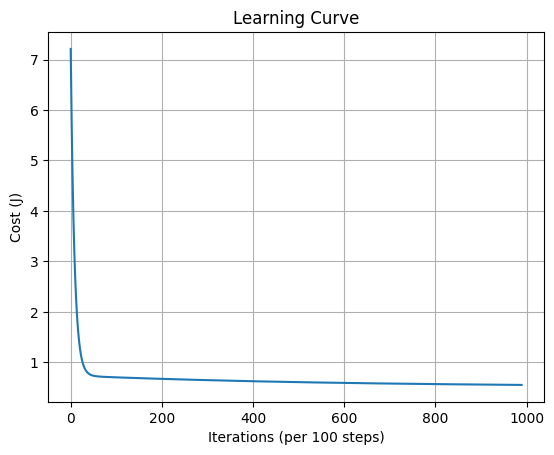

In [39]:
plt.plot(J_hist)
plt.xlabel("Iterations (per 100 steps)")
plt.ylabel("Cost (J)")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

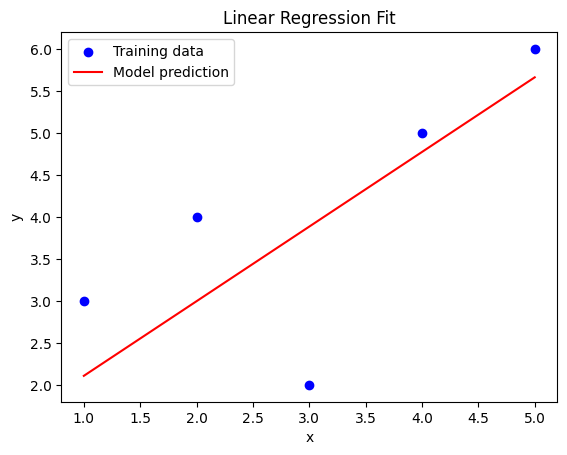

In [40]:
y_pred = w_final * x + b_final

plt.scatter(x, y, color='blue', label='Training data')
plt.plot(x, y_pred, color='red', label='Model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [49]:
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6]
])

y = np.array([5, 7, 9, 11, 13])

In [50]:
w_init = np.zeros(X.shape[1])  # two weights
b_init = 0.0
alpha = 0.01
num_iters = 1000

# Run gradient descent
w_final, b_final, J_hist = batch_gradient_descent(
    X, y, w_init, b_init,
    compute_cost, compute_gradient,
    alpha, num_iters
)
print(f"\nFinal parameters:\nw = {w_final}\nb = {b_final:.4f}")

Itr: 1 | Cost: 23.41981346375 | w: [0.2868  0.37025] | b: 0.08345
Itr: 2 | Cost: 17.007352944478562 | w: [0.39885675 0.5151825 ] | b: 0.11632575
Itr: 3 | Cost: 12.363275434042544 | w: [0.49411197 0.63856959] | b: 0.14445762
Itr: 4 | Cost: 8.999883192456027 | w: [0.57506907 0.74362133] | b: 0.1685522606375
Itr: 5 | Cost: 6.563979419542654 | w: [0.6438585  0.83306953] | b: 0.189211036536375
Itr: 6 | Cost: 4.799774577075428 | w: [0.70229325 0.90923896] | b: 0.20694571321132313
Itr: 7 | Cost: 3.5220226835782165 | w: [0.75191621 0.97410801] | b: 0.22219180672954858
Itr: 8 | Cost: 2.596566283209326 | w: [0.79404038 1.02936032] | b: 0.2353199443630585
Itr: 9 | Cost: 1.9262468690280166 | w: [0.82978313 1.07642867] | b: 0.2466455325805325
Itr: 10 | Cost: 1.440701035396352 | w: [0.86009537 1.11653236] | b: 0.256436984573731
Itr: 11 | Cost: 1.0889707239946993 | w: [0.88578631 1.15070903] | b: 0.2649227219380626
Itr: 12 | Cost: 0.834151471610007 | w: [0.90754459 1.17984172] | b: 0.2722971331500584

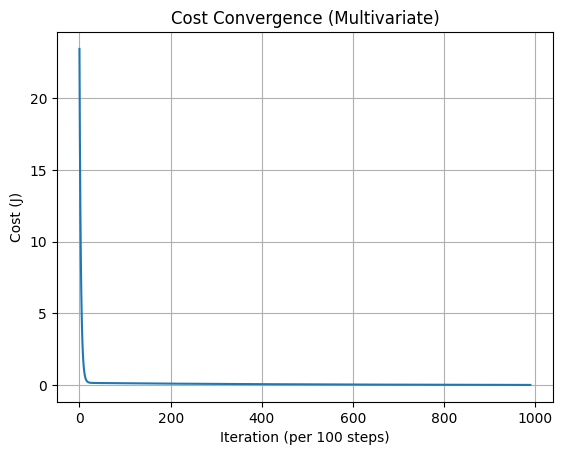

In [51]:
plt.plot(J_hist)
plt.xlabel("Iteration (per 100 steps)")
plt.ylabel("Cost (J)")
plt.title("Cost Convergence (Multivariate)")
plt.grid(True)
plt.show()

In [52]:
def predict(X,w,b):
    return np.dot(X, w_final)+b

In [53]:
predict([6,5],w_final,b_final)

np.float64(12.25093237314599)